# Libraries

In [275]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [276]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240507 - Ag60 GDE_0.9 M Na2SO4_pH1

11-Aug-26  03:50 PM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
07-Jun-26  12:11 PM    <DIR>          .ipynb_checkpoints
08-May-24  10:39 AM            32,675 0p9M_pH1 Na2SO4_20240508_0839_1min - Copy.xlsx
03-Aug-26  12:05 PM            47,219 0p9M_pH1 Na2SO4_20240508_0839_1min.xlsx
08-May-24  10:39 AM           249,796 0p9M_pH1 Na2SO4_20240508_0839_Line_1.csv
19-Jul-25  05:37 PM           784,304 20240507 - Ag60 GDE_0.9 M Na2SO4_pH1.ipynb
11-Aug-26  03:50 PM           734,328 20240507 - Ag60 GDE_0.9 M Na2SO4_pH1-CORRECTED.ipynb
11-Aug-26  03:48 PM               574 20240507_0.9 M Na2SO4_pH1_Energy Consumption.csv
11-Aug-26  03:50 PM             5,138 20240507_0.9M Na2SO4_pH1.csv
11-Aug-26  03:48 PM             1,407 20240507_0.9M Na2SO4_pH1_flow rate.csv
07-Jun-26  02:51 PM           109,165 

# Load Data

In [277]:
Book = "Book_20240507 - Ag60 GDE_0.9 M Na2SO4_pH1.xlsx"
Book = pd.read_excel(Book)
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60,0.000000,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-07 17:13:00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN
1,Ag60 GDE in PTFE holder,60,46.687634,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-07 17:36:00,0.383333,1.716183,...,0.016520,0.000000,0.921528,0.013186,0.816654,0.000000,NaN,0.816654,0.000000,NaN
2,Ag60 GDE in PTFE holder,60,55.572289,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-07 18:28:00,1.250000,1.749588,...,0.017050,0.000000,0.979495,0.001113,1.003239,0.000000,NaN,1.003239,0.000000,100.511085
3,Ag60 GDE in PTFE holder,60,58.396965,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-07 19:04:00,1.850000,1.695987,...,0.016506,0.000000,0.980764,0.000840,1.020593,0.000000,NaN,1.020593,0.000000,NaN
4,Ag60 GDE in PTFE holder,60,60.111221,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-07 19:29:00,2.266667,3.158875,...,0.030774,0.000000,0.967180,0.000660,0.906784,0.000000,NaN,0.906784,0.000000,99.279628
5,Ag60 GDE in PTFE holder,60,60.401743,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-07 19:55:00,2.700000,3.417836,...,0.033287,0.000000,0.965045,0.000555,0.985595,0.000000,NaN,0.985595,0.000000,NaN
6,Ag60 GDE in PTFE holder,60,60.878372,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-07 20:31:00,3.300000,3.406376,...,0.033165,0.000000,0.965266,0.000503,0.989723,0.000000,NaN,0.989723,0.000000,99.141916
7,Ag60 GDE in PTFE holder,60,62.011385,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-07 20:56:00,3.716667,3.385652,...,0.032978,0.000000,0.965828,0.000416,1.002455,0.000000,NaN,1.002455,0.000000,NaN
8,Ag60 GDE in PTFE holder,60,65.106015,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-05-07 21:30:00,4.283333,5.773134,...,0.056218,0.000000,0.942647,0.000399,0.931589,0.000000,NaN,0.931589,0.000000,96.802525
9,Ag60 GDE in PTFE holder,60,64.538812,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-05-07 21:56:00,4.716667,6.112978,...,0.059516,0.000000,0.939456,0.000374,0.977655,0.000000,NaN,0.977655,0.000000,NaN


In [278]:
# Book["FE(CO)"] = round(Book["FE(CO)"]*100,2)
# Book["FE(H2)"] = round(Book["FE(H2)"]*100,2)
Book.head(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60,0.000000,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-07 17:13:00,0.000000,0.000000,...,0.00000,0.0,0.000000,0.000000,0.000000,0.0,NaN,0.000000,0.0,NaN
1,Ag60 GDE in PTFE holder,60,46.687634,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-07 17:36:00,0.383333,1.716183,...,0.01652,0.0,0.921528,0.013186,0.816654,0.0,NaN,0.816654,0.0,NaN
2,Ag60 GDE in PTFE holder,60,55.572289,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-07 18:28:00,1.250000,1.749588,...,0.01705,0.0,0.979495,0.001113,1.003239,0.0,NaN,1.003239,0.0,100.511085


In [279]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
34,Ag60 GDE in PTFE holder,60,69.54,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-05-08 10:15:00,17.03,15.891705,...,0.005468,0.841030,0.000295,2.809471,0.100645,NaN,2.910116,0.006459,88.133610,69.54
35,Ag60 GDE in PTFE holder,60,70.73,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-05-08 10:32:00,17.32,15.896379,...,0.005290,0.841703,0.000220,2.854467,0.099044,NaN,2.953510,0.006246,NaN,70.73
36,Ag60 GDE in PTFE holder,60,55.19,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-05-08 10:57:00,17.73,5.719471,...,0.000031,0.943877,0.000334,0.805929,0.000451,NaN,0.806379,0.000033,97.860123,55.19


### Temp from pH meter

In [280]:
Temp = "2024-05-08_104319.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 23.55146641438032
Temp C median: 23.4


## Power supply

In [281]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,0.00V,0.21V,0.000A,0.000A,320.00W,0.00W,NaN,NaN,NaN,On,CV,NaN,07.05.2024 17:13:23.920
1,40.00V,3.01V,0.100A,0.111A,320.00W,0.00W,NaN,NaN,NaN,On,CC,NaN,07.05.2024 17:13:28.905


In [282]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set            
0.000A 0    0.21V
0.100A 1    3.01V
       2    3.08V

In [283]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "max",
        "U actual": "max"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                 Time  I actual  U actual
0 2024-05-07 16:00:00     0.122      3.17
1 2024-05-07 18:00:00     0.270      3.18
2 2024-05-07 20:00:00     0.517      3.82
3 2024-05-07 22:00:00     0.771      4.46
4 2024-05-08 00:00:00     1.020      5.15
5 2024-05-08 02:00:00     1.514      6.42
6 2024-05-08 04:00:00     2.022      7.42
7 2024-05-08 06:00:00     3.015      8.93
8 2024-05-08 08:00:00     3.021      8.92
9 2024-05-08 10:00:00     1.516      5.99


In [284]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-2].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-05-07 16:00:00     0.122      3.17
1 2024-05-07 18:00:00     0.270      3.18
2 2024-05-07 20:00:00     0.517      3.82
3 2024-05-07 22:00:00     0.771      4.46
4 2024-05-08 00:00:00     1.020      5.15
5 2024-05-08 02:00:00     1.514      6.42
6 2024-05-08 04:00:00     2.022      7.42
7 2024-05-08 06:00:00     3.015      8.93


In [285]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [286]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.122,3.17
0.270,3.18
0.517,3.82
0.771,4.46
1.020,5.15
1.514,6.42
2.022,7.42
3.015,8.93


In [287]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.122,3.17,1.22
0.270,3.18,2.70
0.517,3.82,5.17
0.771,4.46,7.71
1.020,5.15,10.20
1.514,6.42,15.14
2.022,7.42,20.22
3.015,8.93,30.15


## Flow rate

In [288]:
flow_rate = "0p9M_pH1 Na2SO4_20240508_0839_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-05-08 08:39:14.026000,NaN
1,Software version,Aurora 1.0.6,NaN
2,Instrument name,0p9M_pH1 Na2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6f:0d:ec,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [289]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-05-07 15:13:59.981000,42.819138,21.409569
1,2024-05-07 15:15:00.029000,42.664691,21.332345
2,2024-05-07 15:15:59.990000,42.686048,21.343024
3,2024-05-07 15:17:00.038000,42.858254,21.429127
4,2024-05-07 15:18:00,42.336239,21.168119
...,...,...,...
971,2024-05-08 07:25:00.019000,69.153096,34.576548
972,2024-05-08 07:25:59.981000,69.465205,34.732602
973,2024-05-08 07:27:00.029000,68.245882,34.122941
974,2024-05-08 07:27:59.990000,68.66617,34.333085


In [290]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-05-07 14:00:00     41.799402      54.10108      47.876623   
1 2024-05-07 16:00:00     53.826165     61.372141      57.754911   
2 2024-05-07 18:00:00     60.241537     65.267503      62.659474   
3 2024-05-07 20:00:00     64.004403     68.721574      65.889937   
4 2024-05-07 22:00:00     65.702098      70.43423      67.812623   
5 2024-05-08 00:00:00     67.211061     74.809576      70.195965   
6 2024-05-08 02:00:00     70.154575     75.486278      72.631995   
7 2024-05-08 04:00:00     71.346781     81.080203      75.368677   
8 2024-05-08 06:00:00     67.722466     80.215908      77.040972   

  Flow_rate_median  
0        47.657612  
1        57.400687  
2        62.011385  
3        65.360198  
4        67.516025  
5         69.46243  
6        72.403126  
7        73.739102  
8        78.679684  


### Correction dry flow

In [291]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.333 L/mol
p_sat = 2.8786 kPa -> x(H2O) = 2.84 % -> dry factor 0.97159


In [292]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [293]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-1].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-05-07 14:00:00,41.799402,54.10108,47.876623,47.657612,40.611898,52.564091,46.516468,46.303679,0.122,3.17
1,2024-05-07 16:00:00,53.826165,61.372141,57.754911,57.400687,52.296986,59.628584,56.114118,55.769957,0.270,3.18
2,2024-05-07 18:00:00,60.241537,65.267503,62.659474,62.011385,58.5301,63.41328,60.879344,60.249667,0.517,3.82
3,2024-05-07 20:00:00,64.004403,68.721574,65.889937,65.360198,62.186064,66.769222,64.018031,63.503342,0.771,4.46
4,2024-05-07 22:00:00,65.702098,70.43423,67.812623,67.516025,63.835528,68.433223,65.886094,65.597923,1.020,5.15
5,2024-05-08 00:00:00,67.211061,74.809576,70.195965,69.46243,65.301622,72.684267,68.201727,67.489031,1.514,6.42
6,2024-05-08 02:00:00,70.154575,75.486278,72.631995,72.403126,68.161512,73.341744,70.56855,70.346183,2.022,7.42
7,2024-05-08 04:00:00,71.346781,81.080203,75.368677,73.739102,69.319848,78.776748,73.227484,71.644204,3.015,8.93


In [294]:
# dfflow_rate.to_csv('20240507_0.9M Na2SO4_pH1_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J <br>

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [295]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.122,3.17,1.22,122.0
0.270,3.18,2.70,270.0
0.517,3.82,5.17,517.0


In [296]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.122,3.17,1.22,122.0,2784.528
0.270,3.18,2.70,270.0,6181.920
0.517,3.82,5.17,517.0,14219.568
0.771,4.46,7.71,771.0,24758.352
1.020,5.15,10.20,1020.0,37821.600
1.514,6.42,15.14,1514.0,69983.136
2.022,7.42,20.22,2022.0,108023.328
3.015,8.93,30.15,3015.0,193852.440


In [297]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.122,3.17,1.22,122.0,2784.528,0.000773
0.270,3.18,2.70,270.0,6181.920,0.001717
0.517,3.82,5.17,517.0,14219.568,0.003950
0.771,4.46,7.71,771.0,24758.352,0.006877
1.020,5.15,10.20,1020.0,37821.600,0.010506
1.514,6.42,15.14,1514.0,69983.136,0.019440
2.022,7.42,20.22,2022.0,108023.328,0.030006
3.015,8.93,30.15,3015.0,193852.440,0.053848


In [298]:
# dfcell_voltage.to_csv('20240507_0.9 M Na2SO4_pH1_Energy Consumption.csv')

## Integer Duration ("Applied Current /A" - Values optimization)

In [299]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60,0.00,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-07 17:13:00,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.00,0.0
1,Ag60 GDE in PTFE holder,60,46.69,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-07 17:36:00,0.38,1.716183,...,0.921528,0.013186,0.816654,0.000000,NaN,0.816654,0.000000,NaN,46.69,0.0
2,Ag60 GDE in PTFE holder,60,55.57,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-07 18:28:00,1.25,1.749588,...,0.979495,0.001113,1.003239,0.000000,NaN,1.003239,0.000000,100.511085,55.57,1.0
3,Ag60 GDE in PTFE holder,60,58.40,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-07 19:04:00,1.85,1.695987,...,0.980764,0.000840,1.020593,0.000000,NaN,1.020593,0.000000,NaN,58.40,1.0
4,Ag60 GDE in PTFE holder,60,60.11,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-07 19:29:00,2.27,3.158875,...,0.967180,0.000660,0.906784,0.000000,NaN,0.906784,0.000000,99.279628,60.11,2.0
5,Ag60 GDE in PTFE holder,60,60.40,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-07 19:55:00,2.70,3.417836,...,0.965045,0.000555,0.985595,0.000000,NaN,0.985595,0.000000,NaN,60.40,2.0
6,Ag60 GDE in PTFE holder,60,60.88,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-07 20:31:00,3.30,3.406376,...,0.965266,0.000503,0.989723,0.000000,NaN,0.989723,0.000000,99.141916,60.88,3.0
7,Ag60 GDE in PTFE holder,60,62.01,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-07 20:56:00,3.72,3.385652,...,0.965828,0.000416,1.002455,0.000000,NaN,1.002455,0.000000,NaN,62.01,3.0
8,Ag60 GDE in PTFE holder,60,65.11,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-05-07 21:30:00,4.28,5.773134,...,0.942647,0.000399,0.931589,0.000000,NaN,0.931589,0.000000,96.802525,65.11,4.0
9,Ag60 GDE in PTFE holder,60,64.54,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-05-07 21:56:00,4.72,6.112978,...,0.939456,0.000374,0.977655,0.000000,NaN,0.977655,0.000000,NaN,64.54,4.0


## Current Density

In [300]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,0.00,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-07 17:13:00,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.00,0.0,0.0
1,Ag60 GDE in PTFE holder,60,46.69,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-07 17:36:00,0.38,1.716183,...,0.013186,0.816654,0.000000,NaN,0.816654,0.000000,NaN,46.69,0.0,-125.0
2,Ag60 GDE in PTFE holder,60,55.57,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-07 18:28:00,1.25,1.749588,...,0.001113,1.003239,0.000000,NaN,1.003239,0.000000,100.511085,55.57,1.0,-125.0
3,Ag60 GDE in PTFE holder,60,58.40,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-07 19:04:00,1.85,1.695987,...,0.000840,1.020593,0.000000,NaN,1.020593,0.000000,NaN,58.40,1.0,-125.0
4,Ag60 GDE in PTFE holder,60,60.11,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-07 19:29:00,2.27,3.158875,...,0.000660,0.906784,0.000000,NaN,0.906784,0.000000,99.279628,60.11,2.0,-270.0
5,Ag60 GDE in PTFE holder,60,60.40,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-07 19:55:00,2.70,3.417836,...,0.000555,0.985595,0.000000,NaN,0.985595,0.000000,NaN,60.40,2.0,-270.0
6,Ag60 GDE in PTFE holder,60,60.88,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-07 20:31:00,3.30,3.406376,...,0.000503,0.989723,0.000000,NaN,0.989723,0.000000,99.141916,60.88,3.0,-270.0
7,Ag60 GDE in PTFE holder,60,62.01,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-07 20:56:00,3.72,3.385652,...,0.000416,1.002455,0.000000,NaN,1.002455,0.000000,NaN,62.01,3.0,-270.0
8,Ag60 GDE in PTFE holder,60,65.11,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-05-07 21:30:00,4.28,5.773134,...,0.000399,0.931589,0.000000,NaN,0.931589,0.000000,96.802525,65.11,4.0,-520.0
9,Ag60 GDE in PTFE holder,60,64.54,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-05-07 21:56:00,4.72,6.112978,...,0.000374,0.977655,0.000000,NaN,0.977655,0.000000,NaN,64.54,4.0,-520.0


## FE(CO)

In [301]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [302]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.333 L/mol


In [303]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.122, 0.27, 0.517, 0.771, 1.02, 1.514, 2.022, 3.015]

In [304]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[4, 4, 4, 4, 4, 4, 4, 4]

In [305]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))
# rows[["c(H2)", "c(CO)","FE(H2)", "FE(CO)"]].head(50)

                     c(H2)  c(CO)
Applied current / A              
0.122                0.017  0.000
0.270                0.033  0.000
0.517                0.060  0.000
0.771                0.085  0.000
1.020                0.109  0.000
1.514                0.143  0.012
2.022                0.163  0.039
3.015                0.228  0.049


In [306]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    # # Debug
    # debug = pd.DataFrame({
    #     'current_A'   : current_A.abs(),
    #     'conc'        : conc,
    #     'flow_ml_min' : flow_ml_min,
    #     'flow_L_s'    : flow_L_s,
    #     'mol_per_s'   : mol_per_s,
    #     'charge_rate' : charge_rate,
    #     'FE'          : FE
    # })
    # print(debug.to_string())
    # print("---")
    return FE

# rows["FE(CO)"] = faradaic_efficiency(
#     rows["c(CO)"], 
#     rows["Flow rate (ml min-1)"], 
#     rows["Applied current / A"])

# rows["FE(H2)"] = faradaic_efficiency(
#     rows["c(H2)"], 
#     rows["Flow rate (ml min-1)"], 
#     rows["Applied current / A"])


rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 93.2 / 87.2 %


In [307]:
# rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
# rows = rows.drop(rows[rows['Duration / h'] == 2.27].index)
# rows = rows.drop(rows[rows['Duration / h'] == 4.28].index)
# rows = rows.drop(rows[rows['Duration / h'] == 6.3].index)
# rows

### Mean FE per current density

In [308]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        122   62.801949    0.000000     82.838071      0.000000  20.943613   
1        270   88.868788    0.000000     90.289855      0.000000   1.626809   
2        517   90.580173    0.000000     91.814738      0.000000   1.331790   
3        771   91.919965    0.000000     92.511289      0.000000   0.754531   
4       1020   92.648715    0.014436     93.061806      0.013963   0.470717   
5       1514   83.941301    7.318690     84.128563      7.295835   0.597357   
6       2022   75.198739   17.497248     75.024522     17.803427   1.044593   
7       3015   71.276034   15.388596     71.479244     15.462134   0.901309   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0   0.000000  41.887226   0.000000  62.101807  ...   0.012519     0.016513  4   
1   0.000000   3.253617   0.000000  88.529889  ...   0.032551     0.033072  4   
2   0.000000   2.663580   0.000000  90.404044

## FE(H2)

In [309]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]
print(rows["FE(H2)"])

0      0.000000
1     82.873731
2     85.531654
3     82.802410
4     84.016258
5     90.879182
6     90.545278
7     90.034432
8     86.593528
9     91.674216
10    91.955261
11    92.097686
12    92.733947
13    92.961733
14    89.695547
15    92.288632
16    91.251371
17    92.922511
18    93.201101
19    93.219878
20    85.129913
21    84.550286
22    82.378164
23    83.706841
24    73.054175
25    73.971147
26    76.077898
27    77.691735
28    72.261409
29    69.028373
30    70.697079
31    73.117276
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

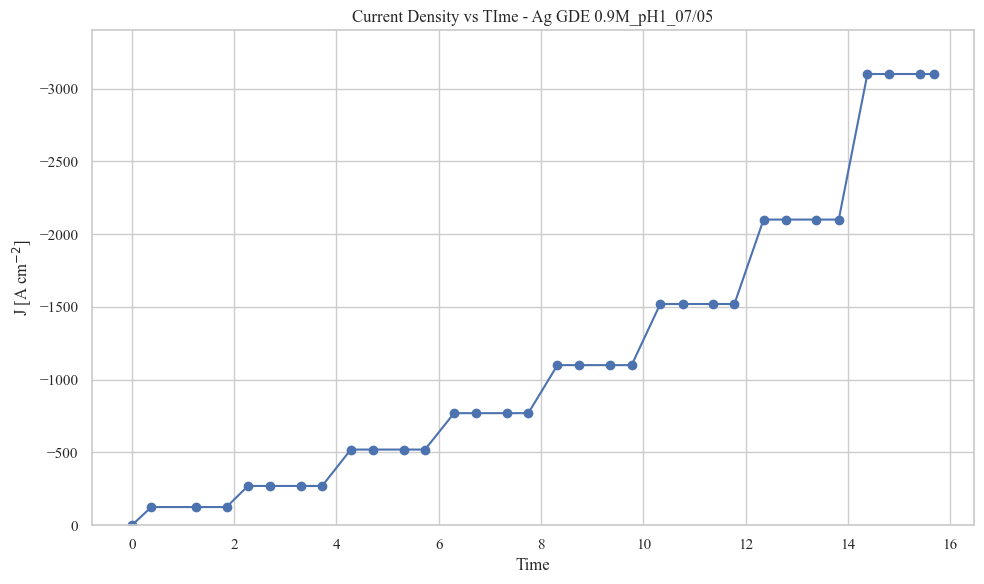

In [310]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.9M_pH1_07/05')  
plt.xlabel('Time') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

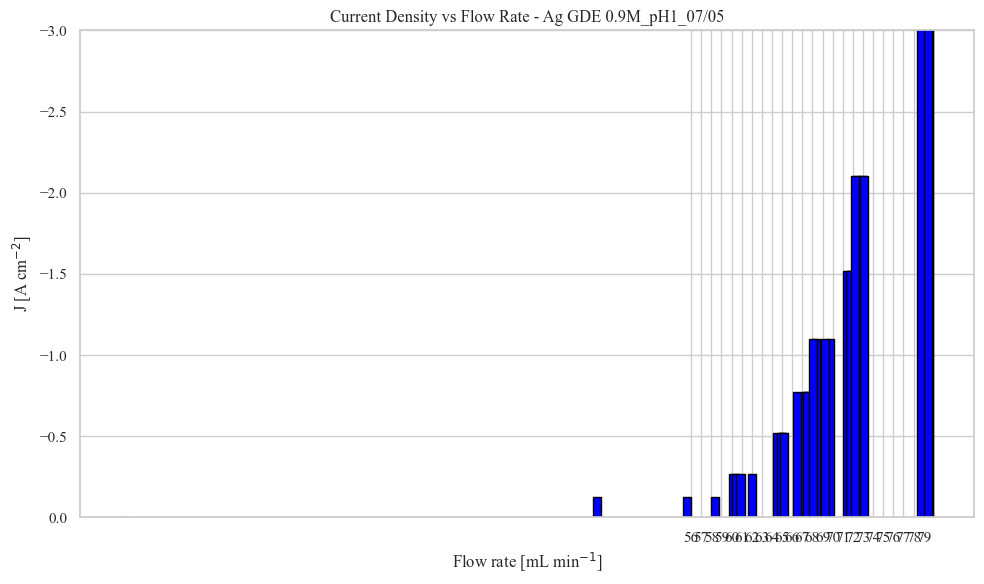

In [311]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.9M_pH1_07/05')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


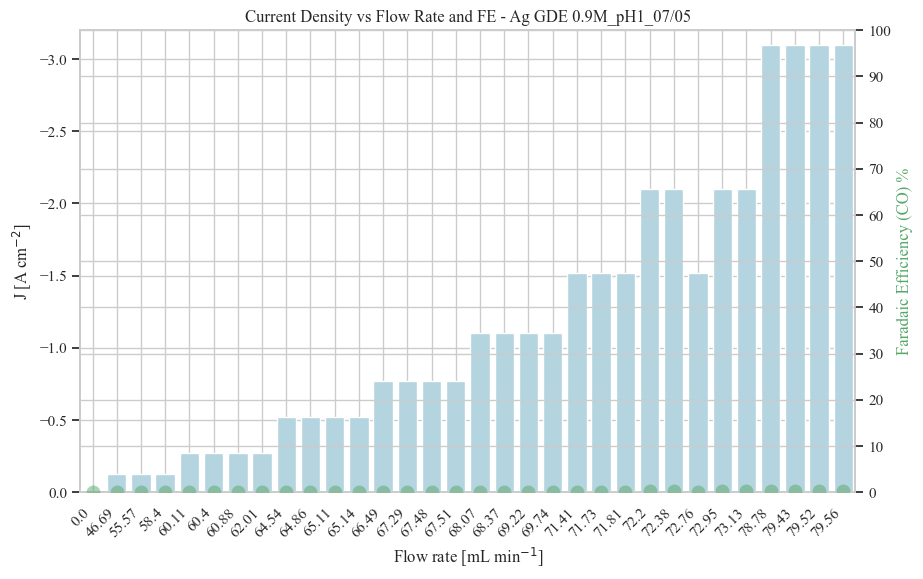

In [312]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.9M_pH1_07/05')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240507_Ag_GDE_0_9M_pH1_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [313]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [314]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240507 - Ag60 GDE_0.9 M Na2SO4_pH1

11-Aug-26  03:50 PM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
07-Jun-26  12:11 PM    <DIR>          .ipynb_checkpoints
08-May-24  10:39 AM            32,675 0p9M_pH1 Na2SO4_20240508_0839_1min - Copy.xlsx
03-Aug-26  12:05 PM            47,219 0p9M_pH1 Na2SO4_20240508_0839_1min.xlsx
08-May-24  10:39 AM           249,796 0p9M_pH1 Na2SO4_20240508_0839_Line_1.csv
19-Jul-25  05:37 PM           784,304 20240507 - Ag60 GDE_0.9 M Na2SO4_pH1.ipynb
11-Aug-26  03:50 PM           734,328 20240507 - Ag60 GDE_0.9 M Na2SO4_pH1-CORRECTED.ipynb
11-Aug-26  03:48 PM               574 20240507_0.9 M Na2SO4_pH1_Energy Consumption.csv
11-Aug-26  03:50 PM             5,138 20240507_0.9M Na2SO4_pH1.csv
11-Aug-26  03:48 PM             1,407 20240507_0.9M Na2SO4_pH1_flow rate.csv
07-Jun-26  02:51 PM           109,165 

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


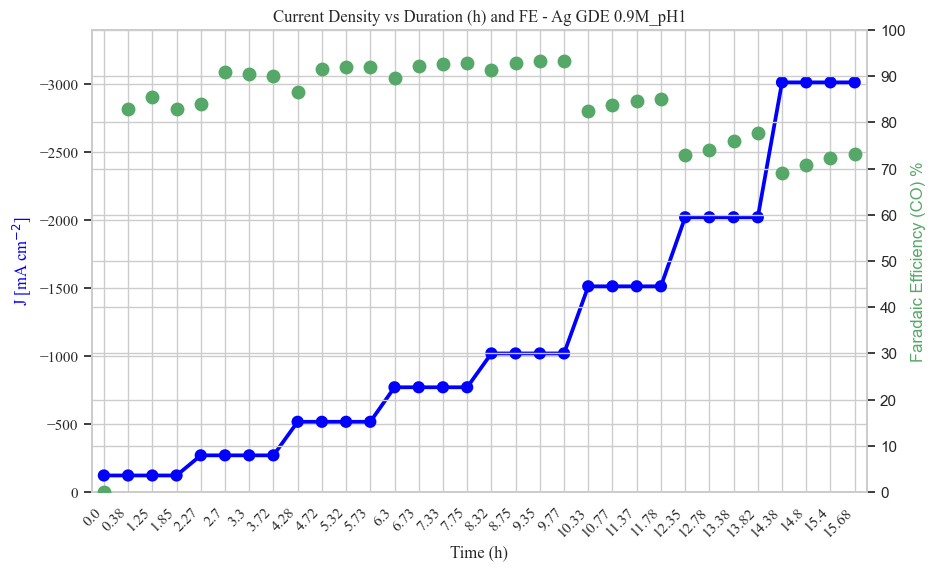

In [315]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.9M_pH1')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(H2)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))
# plt.savefig('20240507_Ag_GDE_0_9M_pH1_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

#### Drop points at initial step in each current

In [316]:
# rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
# rows = rows.drop(rows[rows['Duration / h'] == 2.27].index)
# rows = rows.drop(rows[rows['Duration / h'] == 4.28].index)
# rows = rows.drop(rows[rows['Duration / h'] == 6.3].index)
# rows

## Current Density vs FE(CO)_ mean and std

## Stacked bar plot

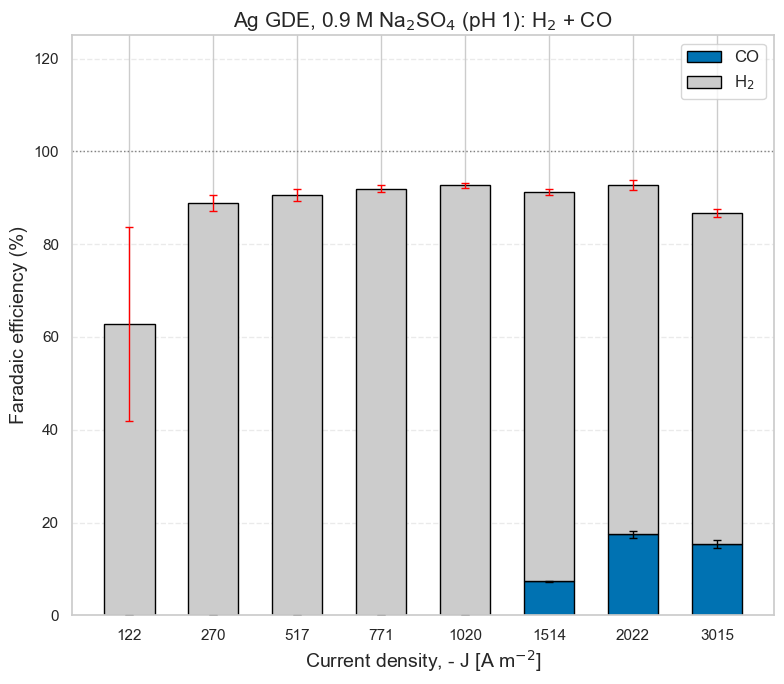

In [317]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.9 M Na$_2$SO$_4$ (pH 1): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

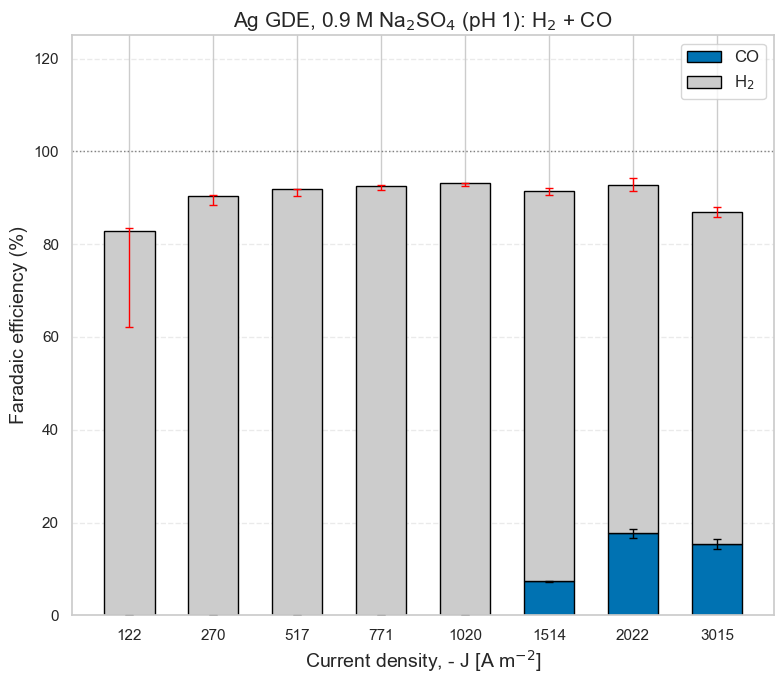

In [320]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.9 M Na$_2$SO$_4$ (pH 1): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [321]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [322]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,62.801949,0.000000,82.838071,0.000000,20.943613,0.000000,41.887226,0.000000,62.101807,...,0.016513,4,20.736263,0.700141,0.000000,0.000000,20.736263,0.700141,0–2,122
1,250,88.868788,0.000000,90.289855,0.000000,1.626809,0.000000,3.253617,0.000000,88.529889,...,0.033072,4,1.759966,0.338899,0.000000,0.000000,1.759966,0.338899,2–4,270
2,500,90.580173,0.000000,91.814738,0.000000,1.331790,0.000000,2.663580,0.000000,90.404044,...,0.059608,4,1.410694,0.176129,0.000000,0.000000,1.410694,0.176129,4–6,517
3,750,91.919965,0.000000,92.511289,0.000000,0.754531,0.000000,1.509061,0.000000,91.640361,...,0.084978,4,0.870929,0.279604,0.000000,0.000000,0.870929,0.279604,6–8,771
4,1000,92.648715,0.014436,93.061806,0.013963,0.470717,0.002125,0.941434,0.004249,92.504726,...,0.109480,4,0.557080,0.143989,0.002550,0.003023,0.560297,0.143785,8–10,1020
5,1500,83.941301,7.318690,84.128563,7.295835,0.597357,0.173994,1.194715,0.347989,83.374671,...,0.142787,4,0.753892,0.566629,0.120486,0.143341,0.662602,0.246214,10–12,1514
6,2000,75.198739,17.497248,75.024522,17.803427,1.044593,0.756807,2.089185,1.513613,73.741904,...,0.163154,4,1.282618,1.456835,1.130204,0.824024,0.458594,0.193851,12–14,2022
7,3000,71.276034,15.388596,71.479244,15.462134,0.901309,0.779736,1.802619,1.559472,70.279903,...,0.227583,4,1.199341,0.996131,1.091072,1.017534,0.250807,0.112059,14–16,3015


In [325]:
Res_Book
# Res_Book.to_csv('20240507_0.9M Na2SO4_pH1.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,62.801949,0.000000,82.838071,0.000000,20.943613,0.000000,41.887226,0.000000,62.101807,...,0.016513,4,20.736263,0.700141,0.000000,0.000000,20.736263,0.700141,0–2,122
1,250,88.868788,0.000000,90.289855,0.000000,1.626809,0.000000,3.253617,0.000000,88.529889,...,0.033072,4,1.759966,0.338899,0.000000,0.000000,1.759966,0.338899,2–4,270
2,500,90.580173,0.000000,91.814738,0.000000,1.331790,0.000000,2.663580,0.000000,90.404044,...,0.059608,4,1.410694,0.176129,0.000000,0.000000,1.410694,0.176129,4–6,517
3,750,91.919965,0.000000,92.511289,0.000000,0.754531,0.000000,1.509061,0.000000,91.640361,...,0.084978,4,0.870929,0.279604,0.000000,0.000000,0.870929,0.279604,6–8,771
4,1000,92.648715,0.014436,93.061806,0.013963,0.470717,0.002125,0.941434,0.004249,92.504726,...,0.109480,4,0.557080,0.143989,0.002550,0.003023,0.560297,0.143785,8–10,1020
5,1500,83.941301,7.318690,84.128563,7.295835,0.597357,0.173994,1.194715,0.347989,83.374671,...,0.142787,4,0.753892,0.566629,0.120486,0.143341,0.662602,0.246214,10–12,1514
6,2000,75.198739,17.497248,75.024522,17.803427,1.044593,0.756807,2.089185,1.513613,73.741904,...,0.163154,4,1.282618,1.456835,1.130204,0.824024,0.458594,0.193851,12–14,2022
7,3000,71.276034,15.388596,71.479244,15.462134,0.901309,0.779736,1.802619,1.559472,70.279903,...,0.227583,4,1.199341,0.996131,1.091072,1.017534,0.250807,0.112059,14–16,3015


## Mean and StD of FE(CO) through time

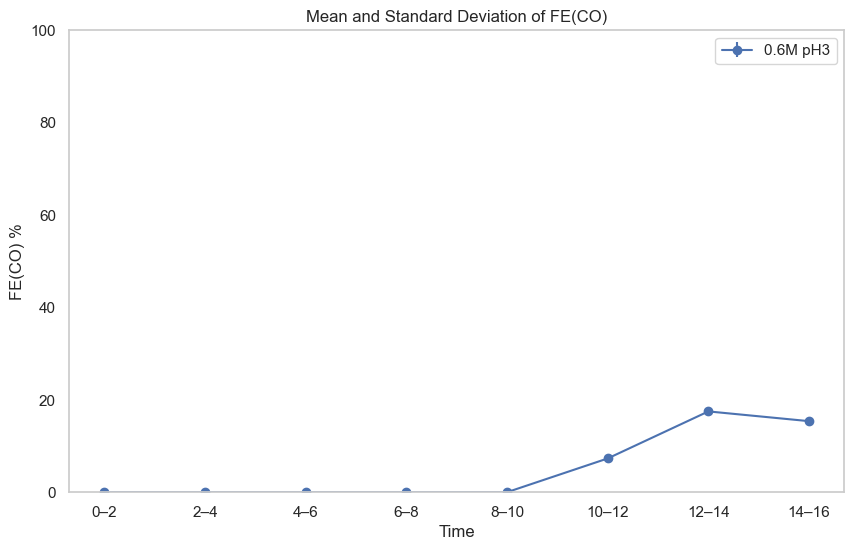

In [326]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Applied Current mean with standard deviation
# ax.errorbar(resampled_df.index, resampled_df['Applied current / A_mean'], 
#             yerr=resampled_df['Applied current / A_std'], fmt='-o', label='Applied current / A_mean')

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.6M pH3')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240507_0.9M_pH1_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

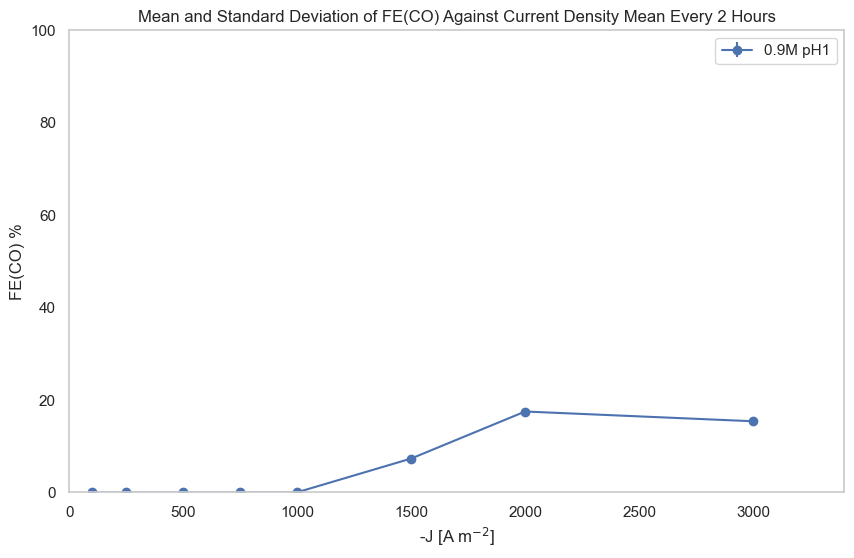

In [327]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.9M pH1')

# Formatting the plot
ax.set_xlabel(r'-J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3400)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240507_0.9M_pH1_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()